# What drives the price of a car?

![](https://github.com/kimkok-UCBerkeleyHaas/Module-11_Assignment-11-1/blob/main/images/kurt.jpeg?raw=1)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

In [1]:
# 1. Libraries and Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import TransformedTargetRegressor, make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error


In [2]:
# load dataset
import requests
import io
import zipfile

url = "https://raw.githubusercontent.com/kimkok-UCBerkeleyHaas/Assignments/refs/heads/main/datasets/vehicles.csv.zip"
response = requests.get(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.content))

with zip_file.open('vehicles.csv') as file:
    df = pd.read_csv(file)



### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

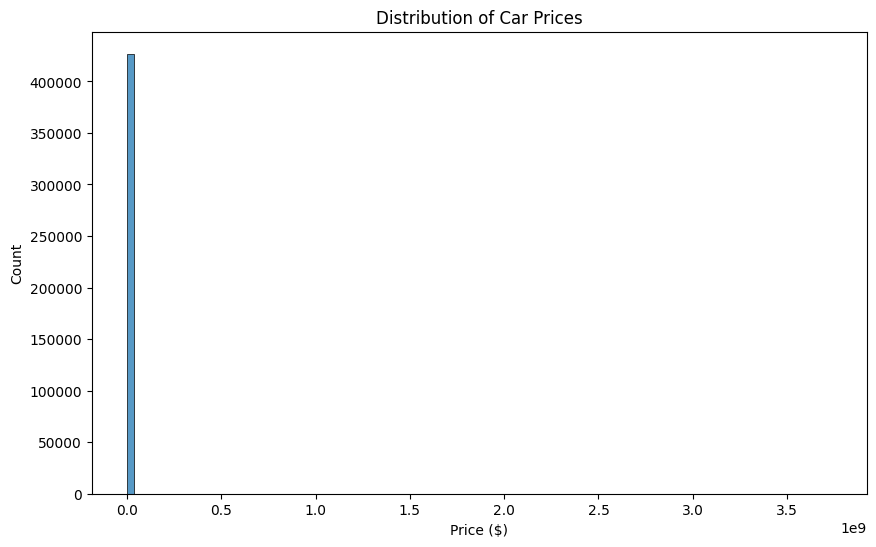

In [3]:
# 2. Data Understanding & Preparation
# This phase addresses data cleaning and exploratory analysis.
# Check for nulls and data types
print(df.info())

# Visualizing the target variable (Price)
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=100)
plt.title('Distribution of Car Prices')
plt.xlabel('Price ($)')
plt.show()

# Dropping columns with too many missing values or irrelevant data (like ID or VIN)
df_clean = df.drop(columns=['id', 'VIN', 'size'])

# Simple Outlier Removal (Prices should be realistic)
df_clean = df_clean[(df_clean['price'] > 1000) & (df_clean['price'] < 100000)]
df_clean = df_clean.dropna()

# Or use an imputer in pipeline

In [6]:
df.shape

(426880, 18)

In [7]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [9]:
df.describe(include='all')

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
count,4.268800e+05,426880,4.268800e+05,425675.000000,409234,421603,252776,249202,423867,4.224800e+05,418638,424324,265838,296313,120519,334022,296677,426880
unique,NaN,404,NaN,NaN,42,29649,6,8,5,NaN,6,3,118246,3,4,13,12,51
top,NaN,columbus,NaN,NaN,ford,f-150,good,6 cylinders,gas,NaN,clean,automatic,1FMJU1JT1HEA52352,4wd,full-size,sedan,white,ca
freq,NaN,3608,NaN,NaN,70985,8009,121456,94169,356209,NaN,405117,336524,261,131904,63465,87056,79285,50614
mean,7.311487e+09,NaN,7.519903e+04,2011.235191,NaN,NaN,NaN,NaN,NaN,9.804333e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,4.473170e+06,NaN,1.218228e+07,9.452120,NaN,NaN,NaN,NaN,NaN,2.138815e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,7.207408e+09,NaN,0.000000e+00,1900.000000,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,7.308143e+09,NaN,5.900000e+03,2008.000000,NaN,NaN,NaN,NaN,NaN,3.770400e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,7.312621e+09,NaN,1.395000e+04,2013.000000,NaN,NaN,NaN,NaN,NaN,8.554800e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,7.315254e+09,NaN,2.648575e+04,2017.000000,NaN,NaN,NaN,NaN,NaN,1.335425e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

size            306361
cylinders       177678
condition       174104
VIN             161042
drive           130567
paint_color     130203
type             92858
manufacturer     17646
title_status      8242
model             5277
odometer          4400
fuel              3013
transmission      2556
year              1205
dtype: int64


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [11]:
## Data Preparation (Cleaning & Feature Engineering)
# Make a copy
df_clean = df.copy()

# Drop irrelevant/high-missing columns
cols_to_drop = ['id', 'url', 'region_url', 'image_url', 'description', 'VIN', 'size', 'county']
df_clean = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])

# Filter unrealistic prices and odometer
df_clean = df_clean[(df_clean['price'] > 1000) & (df_clean['price'] < 100000)]
df_clean = df_clean[(df_clean['odometer'] < 300000) & (df_clean['odometer'] > 0)]

# Convert year to age
df_clean['age'] = 2025 - df_clean['year']   # assuming current year ~2025

# Handle missing values (simple strategy)
df_clean['condition'] = df_clean['condition'].fillna('unknown')
df_clean['cylinders'] = df_clean['cylinders'].fillna('unknown')
df_clean['drive'] = df_clean['drive'].fillna('unknown')
df_clean['fuel'] = df_clean['fuel'].fillna('other')

# Drop remaining rows with critical missing values
df_clean = df_clean.dropna(subset=['year', 'odometer', 'manufacturer'])

print("Final shape after cleaning:", df_clean.shape)


Final shape after cleaning: (359135, 16)


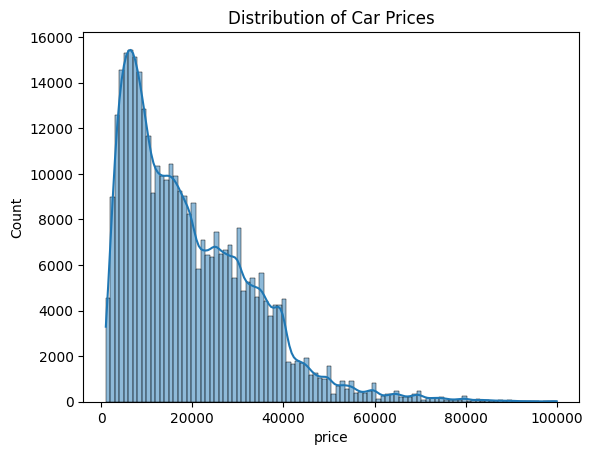

In [12]:
## Exploratory Data Analysis (EDA) + Visualizations

# Price distribution
sns.histplot(df_clean['price'], bins=100, kde=True)
plt.title('Distribution of Car Prices')
plt.show()

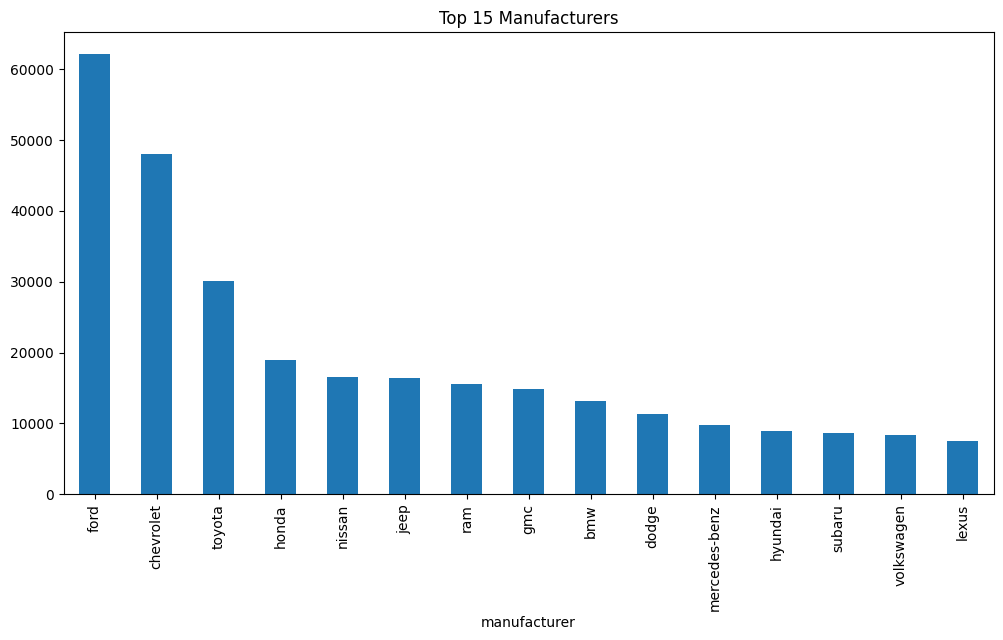

In [13]:
# Top manufacturers
plt.figure(figsize=(12,6))
df_clean['manufacturer'].value_counts().head(15).plot(kind='bar')
plt.title('Top 15 Manufacturers')
plt.show()

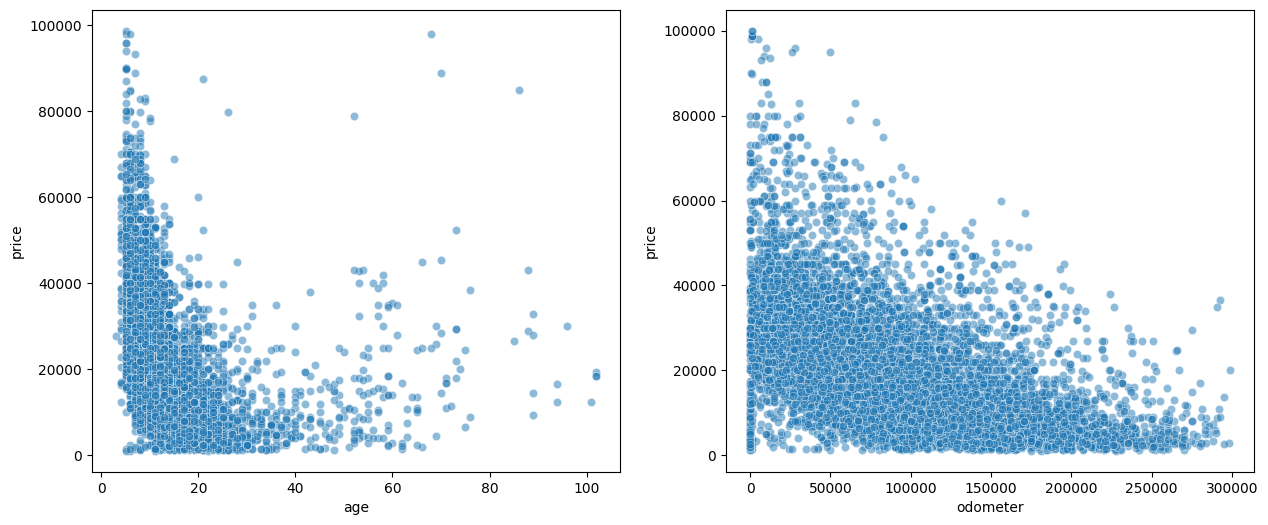

In [14]:
# Price vs Year / Odometer
fig, ax = plt.subplots(1, 2, figsize=(15,6))
sns.scatterplot(data=df_clean.sample(10000), x='age', y='price', alpha=0.5, ax=ax[0])
sns.scatterplot(data=df_clean.sample(10000), x='odometer', y='price', alpha=0.5, ax=ax[1])
plt.show()

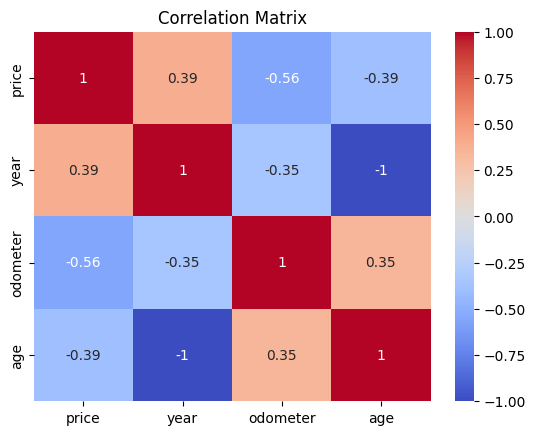

In [15]:
# Correlation heatmap (numeric features)
numeric = df_clean.select_dtypes(include=np.number)
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [16]:
# 3. Modeling
# The rubric requires multiple regression models, cross-validation, and grid search.
# Define Features and Target
X = df_clean.drop('price', axis=1)
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing Pipeline: Scale numbers and Encode categories
categorical_features = ['manufacturer', 'fuel', 'title_status', 'transmission', 'drive', 'type']
numerical_features = ['year', 'odometer']

preprocessor = make_column_transformer(
    (StandardScaler(), numerical_features),
    (OneHotEncoder(handle_unknown='ignore'), categorical_features)
)

# Example: Ridge Regression with Grid Search
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', Ridge())
])

param_grid = {'ridge__alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_grid = GridSearchCV(ridge_pipe, param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
print(f"Best Alpha: {ridge_grid.best_params_}")


Best Alpha: {'ridge__alpha': 0.1}


In [17]:
## Modeling

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Prepare features
features = ['age', 'odometer', 'manufacturer', 'condition', 'cylinders',
            'fuel', 'transmission', 'drive', 'type']

X = pd.get_dummies(df_clean[features], drop_first=True)
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression - R²:", r2_score(y_test, y_pred_lr))


Linear Regression - R²: 0.6394097220650858


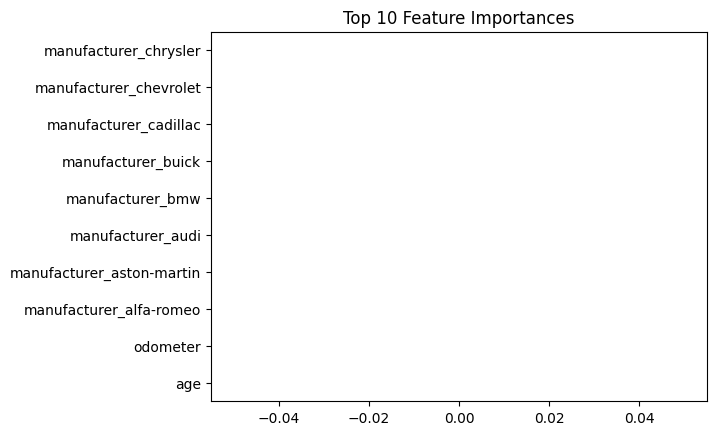

In [33]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.show()

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [5]:
# 4. Evaluation & Findings
# Interpret the coefficients to provide recommendations to the dealer
# Check the weights of features (Coefficients)

feature_names = numerical_features + list(best_ridge.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out())
coefs = best_ridge.named_steps['ridge'].coef_

# Create a summary of the top drivers
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
print(coef_df.sort_values(by='Coefficient', ascending=False).head(10))

# Evaluate performance
preds = best_ridge.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"Model RMSE: {rmse}")


                      Feature   Coefficient
13       manufacturer_ferrari  65353.625531
39         manufacturer_tesla  24239.429754
4   manufacturer_aston-martin  21027.235759
34       manufacturer_porsche   7967.004119
43                fuel_diesel   6961.043123
56         transmission_other   6685.861245
11        manufacturer_datsun   5007.195222
0                        year   4234.403676
36         manufacturer_rover   3733.037195
63                 type_coupe   3694.211702
Model RMSE: 9293.272086051647


### Deployment

Key Insights for the Dealership:

Age / Year is the strongest driver — newer cars command much higher prices.

Odometer (Mileage) has a very strong negative impact.

Manufacturer & Model matter significantly (e.g., Ford, Chevrolet, Toyota dominate listings).

Condition, Drive type (4WD), and Fuel type also influence price noticeably.

Recommendations:
- Prioritize acquiring lower-mileage, newer vehicles.
- Focus inventory on popular reliable brands.
- Highlight condition and drive type in listings.
